In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_rows", 100)   # or None for unlimited
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 20)

In [27]:
df = pd.read_csv('MissingValues.csv')

In [28]:
df.head(3)

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,Notes,Transit,Access,Interaction,House Rules,Thumbnail Url,Medium Url,Picture Url,XL Picture Url,Host ID,Host URL,Host Name,Host Since,Host Location,Host About,Host Response Time,Host Response Rate,Host Acceptance Rate,Host Thumbnail Url,Host Picture Url,Host Neighbourhood,Host Listings Count,Host Total Listings Count,Host Verifications,Street,Neighbourhood,Neighbourhood Cleansed,Neighbourhood Group Cleansed,City,State,Zipcode,Market,Smart Location,Country Code,Country,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Square Feet,Price,Weekly Price,Monthly Price,Security Deposit,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Calendar Updated,Has Availability,Availability 30,Availability 60,Availability 90,Availability 365,Calendar last Scraped,Number of Reviews,First Review,Last Review,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,6017649,https://www.airb...,20170402075052,2017-04-02,Nice room at Von...,Nice and clean p...,"I offer a cuzy, ...",Nice and clean p...,none,Really nice and ...,NaN,Directly train c...,Acces to shared ...,NaN,NaN,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,1195000,https://www.airb...,Linda,2011-09-22,"Amsterdam, North...",NaN,NaN,NaN,NaN,https://a0.musca...,https://a0.musca...,NaN,1.0,1.0,"email, phone, fa...","Amsterdam, Noord...",NaN,De Baarsjes - Ou...,NaN,Amsterdam,Noord-Holland,1054,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.359927,4.86286,Apartment,Private room,1,1.0,1.0,1.0,Real Bed,"Internet, Wirele...",NaN,50.0,NaN,NaN,NaN,NaN,1,0.0,1,1125,22 months ago,NaN,0,0,0,0,2017-04-02,3,2015-05-10,2015-06-08,90.0,10.0,9.0,10.0,9.0,9.0,9.0,NaN,Amsterdam,flexible,1,0.13,52.3599269689410...,Host Has Profile...
1,9192415,https://www.airb...,20170402075052,2017-04-02,Cozy apartment c...,Cozy 2 person ap...,The appartment h...,Cozy 2 person ap...,none,This is an apart...,NaN,"Vondelpark, Muse...",NaN,NaN,-smoking in the ...,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,47820987,https://www.airb...,Annabel,2015-10-31,"Amsterdam, North...",I'm from belgian...,within a few hours,100.0,NaN,https://a0.musca...,https://a0.musca...,Oud-West,1.0,1.0,"email, phone, re...","Oud-West, Amster...",Oud-West,De Baarsjes - Ou...,NaN,Amsterdam,Noord-Holland,1054 HP,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.361371,4.87386,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"TV, Cable TV, In...",NaN,95.0,NaN,NaN,NaN,15.0,2,40.0,2,7,2 months ago,NaN,0,0,0,0,2017-04-02,16,2015-12-07,2017-01-30,99.0,10.0,10.0,10.0,10.0,10.0,10.0,NaN,Amsterdam,moderate,1,0.99,52.3613710126953...,Host Is Superhos...
2,743788,https://www.airb...,20170402075052,2017-04-02,Le Quartier Sona...,‘Le Quartier Son...,We opened our do...,‘Le Quartier Son...,none,NaN,NaN,NaN,NaN,NaN,The most importa...,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,3897376,https://www.airb...,Oki & Frank,2012-10-17,"Amsterdam, Noord...",We are Oki & Fra...,within a day,100.0,NaN,https://a0.musca...,https://a0.musca...,Oud-West,3.0,3.0,"email, phone, re...","Oud-West, Amster...",Oud-West,De Baarsjes - Ou...,NaN,Amsterdam,North Holland,1054,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.364568,4.87564,Bed & Breakfast,Private room,2,1.0,1.0,1.0,Real Bed,"TV, Internet, Wi...",323.0,160.0,NaN,NaN,NaN,NaN,1,0.0,2,14,today,NaN,3,4,13,178,2017-04-02,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amsterdam,strict,2,NaN,52.3645675684607...,Host Has Profile...


## Visualizing Missing Value Counts

<Axes: >

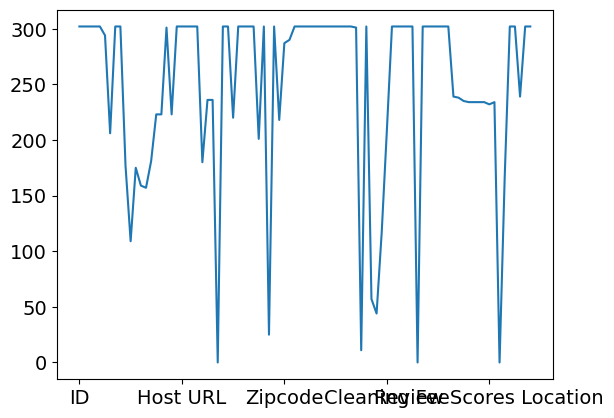

In [29]:
df.describe(include='all').T['count'].plot()

In [57]:
def get_missing_value_percents(df_internal, pct:float = 0.0, clr = 'Blues_r', figsize=(16, 10), fontsize=12):
    plt.rcParams.update({'font.size': 14})

    missing_value_percents = df_internal.isna().sum() / len(df_internal) * 100
    missing_value_percents.sort_values(ascending=False, inplace=True)
    missing_to_plot = missing_value_percents[missing_value_percents > pct]

    n_bars = len(missing_to_plot)
    cmap = plt.get_cmap(clr)
        
    colors = [cmap(i / n_bars * (pct/100)) for i in range(n_bars)]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(missing_to_plot.index, missing_to_plot.values, color=colors)

    # Data labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=fontsize,
            fontweight='bold',
        )

    ax.set_title(f"Percentage of Missing Values by Column (>{pct}%)")
    ax.set_ylabel('% Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return missing_value_percents

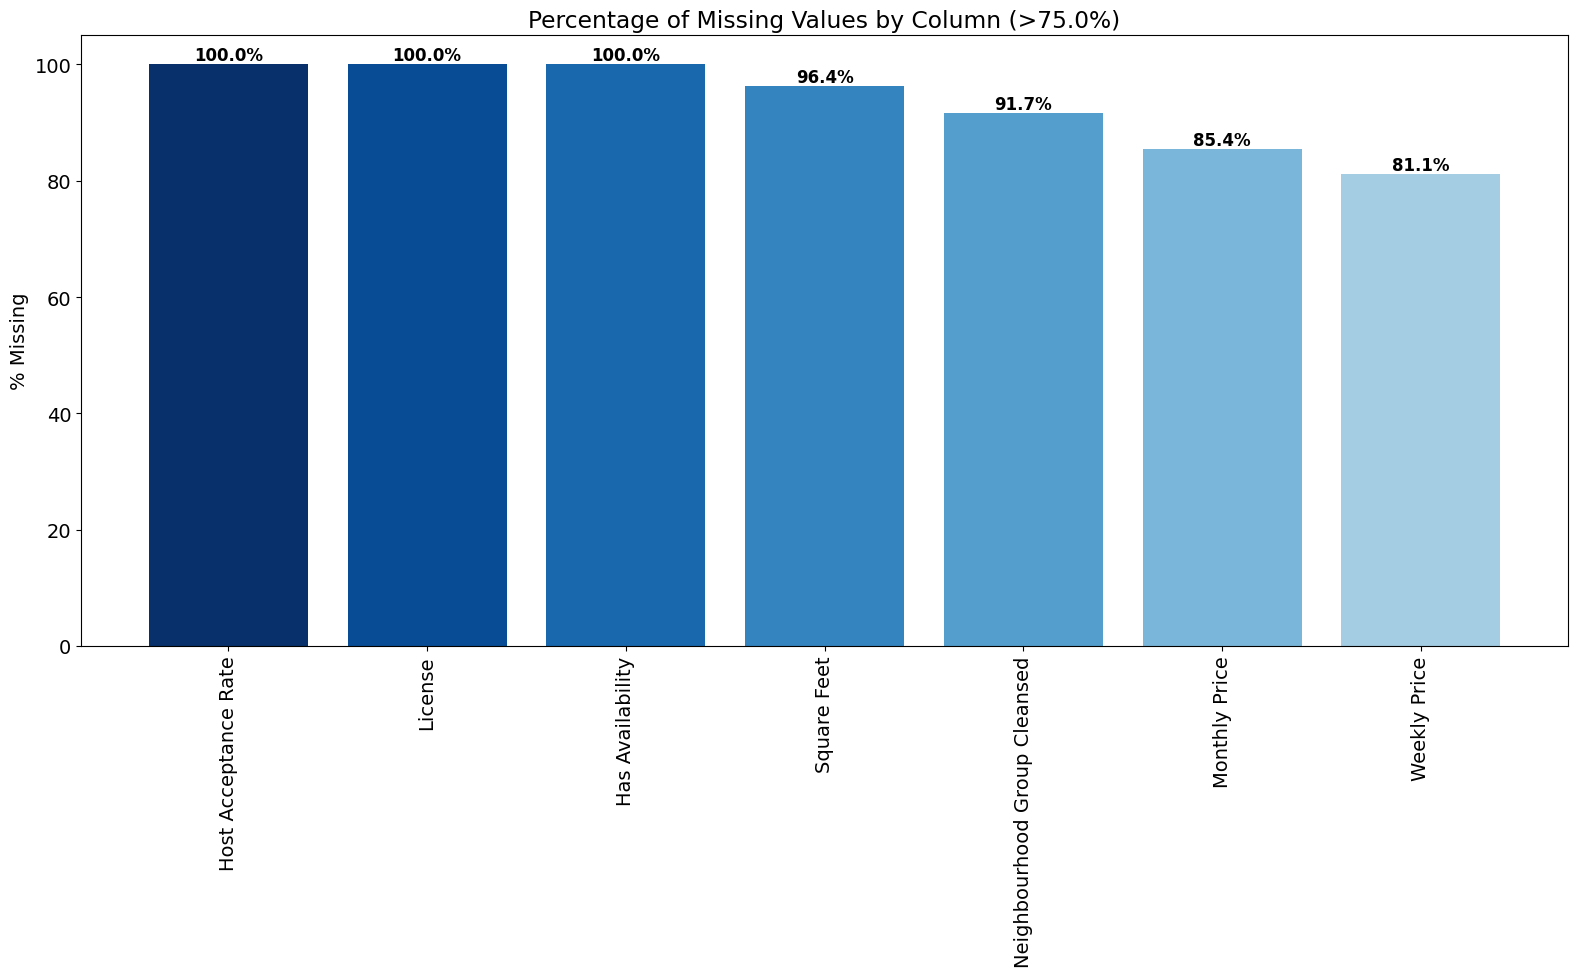

In [60]:
percent_threshold = 75.0
missing_value_percents = get_missing_value_percents(df, pct=percent_threshold)

## Dropping Columns with High Missing Value Counts

In [61]:
columns_with_high_missing_values = missing_value_percents[missing_value_percents > percent_threshold].index.tolist()
columns_with_high_missing_values

['Host Acceptance Rate',
 'License',
 'Has Availability',
 'Square Feet',
 'Neighbourhood Group Cleansed',
 'Monthly Price',
 'Weekly Price']

In [62]:
df.drop(columns=columns_with_high_missing_values, inplace=True)

In [63]:
df.head()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,Notes,Transit,Access,Interaction,House Rules,Thumbnail Url,Medium Url,Picture Url,XL Picture Url,Host ID,Host URL,Host Name,Host Since,Host Location,Host About,Host Response Time,Host Response Rate,Host Thumbnail Url,Host Picture Url,Host Neighbourhood,Host Listings Count,Host Total Listings Count,Host Verifications,Street,Neighbourhood,Neighbourhood Cleansed,City,State,Zipcode,Market,Smart Location,Country Code,Country,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Price,Security Deposit,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Calendar Updated,Availability 30,Availability 60,Availability 90,Availability 365,Calendar last Scraped,Number of Reviews,First Review,Last Review,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,6017649,https://www.airb...,20170402075052,2017-04-02,Nice room at Von...,Nice and clean p...,"I offer a cuzy, ...",Nice and clean p...,none,Really nice and ...,NaN,Directly train c...,Acces to shared ...,NaN,NaN,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,1195000,https://www.airb...,Linda,2011-09-22,"Amsterdam, North...",NaN,NaN,NaN,https://a0.musca...,https://a0.musca...,NaN,1.0,1.0,"email, phone, fa...","Amsterdam, Noord...",NaN,De Baarsjes - Ou...,Amsterdam,Noord-Holland,1054,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.359927,4.862860,Apartment,Private room,1,1.0,1.0,1.0,Real Bed,"Internet, Wirele...",50.0,NaN,NaN,1,0.0,1,1125,22 months ago,0,0,0,0,2017-04-02,3,2015-05-10,2015-06-08,90.0,10.0,9.0,10.0,9.0,9.0,9.0,Amsterdam,flexible,1,0.13,52.3599269689410...,Host Has Profile...
1,9192415,https://www.airb...,20170402075052,2017-04-02,Cozy apartment c...,Cozy 2 person ap...,The appartment h...,Cozy 2 person ap...,none,This is an apart...,NaN,"Vondelpark, Muse...",NaN,NaN,-smoking in the ...,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,47820987,https://www.airb...,Annabel,2015-10-31,"Amsterdam, North...",I'm from belgian...,within a few hours,100.0,https://a0.musca...,https://a0.musca...,Oud-West,1.0,1.0,"email, phone, re...","Oud-West, Amster...",Oud-West,De Baarsjes - Ou...,Amsterdam,Noord-Holland,1054 HP,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.361371,4.873860,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"TV, Cable TV, In...",95.0,NaN,15.0,2,40.0,2,7,2 months ago,0,0,0,0,2017-04-02,16,2015-12-07,2017-01-30,99.0,10.0,10.0,10.0,10.0,10.0,10.0,Amsterdam,moderate,1,0.99,52.3613710126953...,Host Is Superhos...
2,743788,https://www.airb...,20170402075052,2017-04-02,Le Quartier Sona...,‘Le Quartier Son...,We opened our do...,‘Le Quartier Son...,none,NaN,NaN,NaN,NaN,NaN,The most importa...,https://a0.musca...,https://a0.musca...,https://public.o...,https://a0.musca...,3897376,https://www.airb...,Oki & Frank,2012-10-17,"Amsterdam, Noord...",We are Oki & Fra...,within a day,100.0,https://a0.musca...,https://a0.musca...,Oud-West,3.0,3.0,"email, phone, re...","Oud-West, Amster...",Oud-West,De Baarsjes - Ou...,Amsterdam,North Holland,1054,Amsterdam,"Amsterdam, Nethe...",NL,Netherlands,52.364568,4.875640,Bed & Breakfast,Private room,2,1.0,1.0,1.0,Real Bed,"TV, Internet, Wi...",160.0,NaN,NaN,1,0.0,2,14,today,3,4,13,178,2017-04-02,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amsterdam,strict,2,NaN,52.3645675684607...,Host Has Profile...
3,13153299,https://www.airb...,20170402075052,2017-04-02,Trendy and spaci...,A beautiful 2 be...,This spacious to...,A beautiful 2 be...,none,Seriously one of...,NaN,1 min walk to pu...,If the weather p...,We are at your d...,Feel at home. Pl...,https://a0.musca...,https://a0.musca...,https://pub